# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## COUNTERFACTUAL ANALYSIS OF OPTIMAL SOLUTIONS

### ENVIRONMENT SETUP

In [1]:
import re
import sys

from pathlib         import Path
from IPython.display import display

import numpy    as np
import pandas   as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree  , \
                         export_text
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score  , \
                                    classification_report

In [2]:
def find_project_root(start):
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "instances").exists() and \
           (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate project root containing 'instances' and 'notebooks'."
    )

In [3]:
PROJECT_ROOT = find_project_root(
    Path.cwd()
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
import xopt
import pymedian

### SOLVE ONE INSTANCE AND BUILD MEMORY TABLE

In [5]:
INSTANCES_DIR = PROJECT_ROOT / "instances"


if not INSTANCES_DIR.exists():
    raise FileNotFoundError(f"Instances folder not found: {INSTANCES_DIR}")

In [6]:
instance_name = "pmed11.txt"
instance_path = INSTANCES_DIR / instance_name

summary, details = pymedian.solve_pmedian(
    str(instance_path),
    restarts=8 ,
    max_iter=25,
    factor  =2 ,
)

p = int(summary["p"])
n = int(summary["n"])

memory_rows = []
for idx, sol in enumerate(details["long_term_memory"]):
    binary          = np.array(sol["facilities"]     , dtype=int)
    facilities_zero = tuple   (np.where(binary == 1)[0].tolist())

    memory_rows.append(
        {
            "solution_id"     : idx               ,
            "cost"            : float(sol["cost"]),
            "facilities_zero" : facilities_zero   ,
        }
    )


print(f"Solutions in long-term memory is {len(details['long_term_memory'])}!")

Solutions in long-term memory is 781!


In [7]:
memory_df = pd.DataFrame  (memory_rows  ). \
               sort_values("solution_id"). \
               reset_index(drop=True    )

memory_df.head(10)

,solution_id,cost,facilities_zero
0,0,7813.0,"(97, 182, 192, 200, 203)"
1,1,7770.0,"(97, 166, 182, 200, 283)"
2,2,7802.0,"(97, 166, 182, 200, 259)"
3,3,7799.0,"(97, 166, 182, 200, 255)"
4,4,7806.0,"(97, 166, 182, 200, 244)"
5,5,7794.0,"(97, 166, 182, 200, 243)"
6,6,7823.0,"(97, 166, 182, 200, 217)"
7,7,7790.0,"(97, 166, 182, 200, 211)"
8,8,7796.0,"(97, 166, 182, 200, 210)"
9,9,7773.0,"(97, 166, 182, 200, 208)"


Recover the optimal solution stored in memory:

In [8]:
opt_row = memory_df.loc[
    memory_df["cost"].idxmin()
]

optimal_solution_id = int  (opt_row["solution_id"    ])
optimal_cost        = float(opt_row["cost"           ])
optimal_facilities  = tuple(opt_row["facilities_zero"])


print(f"Optimal solution recovered from memory: S{optimal_solution_id}")
print()

print(f"  Cost      : {optimal_cost  :.2f}")
print(f"  Facilities: {optimal_facilities}")

Optimal solution recovered from memory: S427

  Cost      : 7696.00
  Facilities: (23, 30, 97, 166, 200)


### BUILD THE SWAP GRAPH WITH INTERSECTION

After recovers the optimal solution from long-term memory, we builds a small swap-path graph with the 10 closest solutions.

> Obs.: Each edge represents one swap (intersection = p-1).

In [9]:
swap_graph = nx.DiGraph()

for row in memory_rows:
    sid = int(row["solution_id"])

    swap_graph.add_node(
        sid,
        cost      =float(row["cost"           ]),
        facilities=tuple(row["facilities_zero"]),
    )

facility_sets = {
    int(row["solution_id"    ]) :
    set(row["facilities_zero"])
    for row in memory_rows
}

solution_ids = sorted(facility_sets.keys())

for i, sid_a in enumerate(solution_ids):
    set_a = facility_sets[sid_a]

    for sid_b in solution_ids[i + 1:]:
        set_b = facility_sets[sid_b]

        intersection_size = len(set_a & set_b)

        if intersection_size != p - 1:
            continue

        out_a = list(set_a - set_b)
        in_a  = list(set_b - set_a)

        if len(out_a) != 1 or \
           len(in_a ) != 1:
            continue

        facility_out_a = out_a[0]
        facility_in_a  = in_a [0]

        swap_graph.add_edge(
            sid_a,
            sid_b,
            intersection=intersection_size,
            facility_out=facility_out_a,
            facility_in =facility_in_a ,
        )

        swap_graph.add_edge(
            sid_b,
            sid_a,
            intersection=intersection_size,
            facility_out=facility_in_a ,
            facility_in =facility_out_a,
        )


print(f"G(V, E) = ({swap_graph.number_of_nodes()}, {swap_graph.number_of_edges()})")

G(V, E) = (781, 19172)


Extract the 10 closest solutions by swap path:

In [10]:
undirected_swap_graph = swap_graph.to_undirected()

if optimal_solution_id not in undirected_swap_graph:
    raise ValueError("Optimal solution node is missing from the swap graph.")

In [11]:
distances = nx.single_source_shortest_path_length(
    undirected_swap_graph, source=optimal_solution_id
)

closest_nodes = [
    node
    for node, distance in distances.items()
    if  distance == 1 and node != optimal_solution_id
]

result_rows = []
for rank, node in enumerate(closest_nodes, start=1):
    path_nodes = nx.shortest_path(
        undirected_swap_graph,
        source=optimal_solution_id,
        target=node               ,
    )

    swaps = []
    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        e = swap_graph.edges[u, v]

        swaps.append(
            f"{e['facility_out']}->{e['facility_in']}"
        )

    result_rows.append(
        {
            "rank"        : rank,
            "solution_id" : node,
            "cost"        : swap_graph.nodes[node]["cost"],

            "path"  : " -> ".join(f"S{k}" for k in path_nodes),
            "swaps" : " | " .join(swaps                      ),
        }
    )


closest_df = pd.DataFrame(result_rows)

closest_df.head()

,rank,solution_id,cost,path,swaps
0,1,186,7814.0,S427 -> S186,23->268
1,2,187,7805.0,S427 -> S187,23->249
2,3,188,7709.0,S427 -> S188,23->182
3,4,190,7742.0,S427 -> S190,23->106
4,5,201,7807.0,S427 -> S201,23->73


Small networkX graph (optimal and closests):

In [12]:
small_graph = nx.DiGraph()

small_graph.add_node(
    optimal_solution_id, **swap_graph.nodes[optimal_solution_id]
)

for node in closest_nodes:
    path_nodes = nx.shortest_path(
        undirected_swap_graph,
        source=optimal_solution_id,
        target=node               ,
    )

    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        if not small_graph.has_node(u):
            small_graph.add_node(u, **swap_graph.nodes[u])
        if not small_graph.has_node(v):
            small_graph.add_node(v, **swap_graph.nodes[v])

        if not small_graph.has_edge(u, v):
            small_graph.add_edge(
                u, v, **swap_graph.edges[u, v]
            )


print(f"G\'(V\', E\') = ({small_graph.number_of_nodes()}, {small_graph.number_of_edges()})")

G'(V', E') = (54, 53)


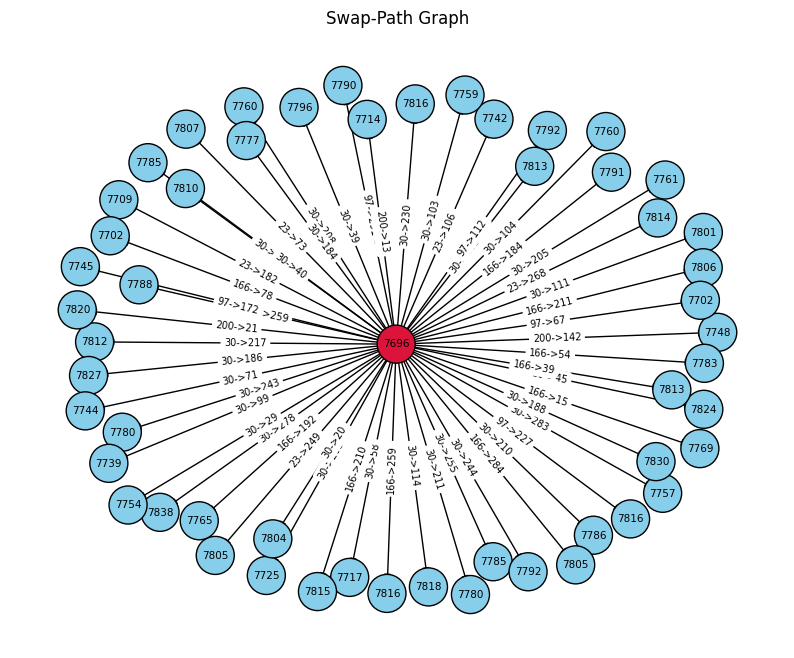

In [13]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(small_graph, seed=42)

nodes      = list    (small_graph.nodes())
node_costs = np.array(
    [
        small_graph.nodes[node]["cost"]
        for node in nodes
    ],
    dtype=float
)

node_colors = []
for node in nodes:
    if node == optimal_solution_id:
        node_colors.append("crimson")
    else:
        node_colors.append("skyblue")

nx.draw_networkx_nodes(
    small_graph,
    pos        ,
    nodelist  =nodes      ,
    node_color=node_colors,
    node_size =750    ,
    edgecolors="black",
)
nx.draw_networkx_edges(
    small_graph,
    pos        ,
    arrows=True,
)

node_labels = {
    node : int(
        small_graph.nodes[node]['cost']
    )
    for node in nodes
}
edge_labels = {
    (u, v) : f"{d['facility_out']}->{d['facility_in']}"
    for u, v, d in small_graph.edges(data=True)
}

nx.draw_networkx_labels     (small_graph, pos, labels     =node_labels, font_size=7.5)
nx.draw_networkx_edge_labels(small_graph, pos, edge_labels=edge_labels, font_size=7  )

plt.title("Swap-Path Graph")
plt.axis ("off")

plt.show()

### LOAD INSTANCE

Explicit instance loading:

In [14]:
instance_obj = xopt.Instance(
    str(instance_path)
)

n_xopt = int(instance_obj.get_n())
p_xopt = int(instance_obj.get_p())

if n_xopt != n or p_xopt != p:
    raise ValueError(
        f"Inconsistency between pymedian and xopt: (n,p)=({n},{p}) vs ({n_xopt},{p_xopt})"
    )


distance_matrix = np.array(
    [
        [
            float(instance_obj[i, j])
            for j in range(n_xopt)
        ]
        for i in range(n_xopt)
    ],
    dtype=np.float64,
)


print(f"Instance loaded ({n_xopt}, {p_xopt})")
print()

print(f"Distance matrix shape is {distance_matrix.shape}!")

Instance loaded (300, 5)

Distance matrix shape is (300, 300)!


For each solution, each facility (demand point) is assigned to its nearest median:

In [15]:
def assign_facilities_to_medians(distance_matrix, medians_zero):
    medians = np.array(
        sorted(
            {
                int(v)
                for v in medians_zero
            }
        ),
        dtype=np.int64
    )

    subset      = distance_matrix[:, medians]
    nearest_pos = np.argmin(subset, axis=1)

    assigned_median   = medians[nearest_pos]
    assigned_distance = subset [
        np.arange(subset.shape[0]), nearest_pos
    ]

    return assigned_median, assigned_distance


def extract_swap(opt_set_zero, alt_facilities_zero):
    alt_set = set(
        int(v) for v in alt_facilities_zero
    )

    facility_out = sorted(opt_set_zero - alt_set)
    facility_in  = sorted(alt_set - opt_set_zero)

    return facility_out[0], facility_in[0]

In [16]:
optimal_set_zero = set(opt_row["facilities_zero"])

alternatives_df = memory_df[
    memory_df["solution_id"] != optimal_solution_id
].copy()

alternatives_df["intersection"] = alternatives_df["facilities_zero"].map(
    lambda facilities: len(set(facilities) & optimal_set_zero)
)

alternatives_df = alternatives_df[
    alternatives_df["intersection"] == p - 1
]


print(f"There are {len(alternatives_df)} alternative solutions at distance 1.")

There are 53 alternative solutions at distance 1.


In [17]:
swaps = alternatives_df["facilities_zero"].map(
    lambda facilities: extract_swap(optimal_set_zero, facilities)
).tolist()

alternatives_df["facility_out_zero"] = [pair[0] for pair in swaps]
alternatives_df["facility_in_zero" ] = [pair[1] for pair in swaps]
alternatives_df["cost_gap"         ] = alternatives_df["cost"] - optimal_cost

alternatives_df = alternatives_df.sort_values(
    ["cost_gap", "solution_id"]
).reset_index(drop=True)

candidate_solution_ids = [
    optimal_solution_id
] + alternatives_df["solution_id"].astype(int).tolist()

solution_facilities_zero = {
    int(row.solution_id) : tuple(
        int(v) for v in row.facilities_zero
    )
    for row in memory_df[
        memory_df["solution_id"].isin(candidate_solution_ids)
    ].itertuples(index=False)
}

assignment_cache = {}
assignment_rows  = []

for sid in candidate_solution_ids:
    assigned_median, assigned_distance = assign_facilities_to_medians(
        distance_matrix, solution_facilities_zero[sid]
    )

    assignment_cache[sid] = {
        "assigned_median"   : assigned_median  ,
        "assigned_distance" : assigned_distance,
    }

    counts = pd.Series      (assigned_median) \
               .value_counts()                \
               .sort_index  ()

    for median_zero, demand_count in counts.items():
        mask = assigned_median == median_zero

        assignment_rows.append(
            {
                "solution_id"         : sid,
                "median_zero"         : int  (median_zero ),
                "assigned_facilities" : int  (demand_count),
                "avg_distance"        : float(assigned_distance[mask].mean()),
            }
        )


assignment_summary_df = pd.DataFrame(assignment_rows).sort_values(
    ["solution_id", "median_zero"]
).reset_index(drop=True)

In [18]:
display(
    alternatives_df[
        [
            "solution_id"      ,
            "cost"             ,
            "cost_gap"         ,
            "facility_out_zero",
            "facility_in_zero" ,
            "facilities_zero"  ,
        ]
    ]
    .head(5)
)

,solution_id,cost,cost_gap,facility_out_zero,facility_in_zero,facilities_zero
0,435,7702.0,6.0,166,78,"(23, 30, 78, 97, 200)"
1,442,7702.0,6.0,97,67,"(23, 30, 67, 166, 200)"
2,188,7709.0,13.0,23,182,"(30, 97, 166, 182, 200)"
3,757,7714.0,18.0,200,13,"(13, 23, 30, 97, 166)"
4,375,7717.0,21.0,30,58,"(23, 58, 97, 166, 200)"


In [19]:
display(
    assignment_summary_df.head(10)
)

,solution_id,median_zero,assigned_facilities,avg_distance
0,186,30,36,26.444444
1,186,97,106,24.500000
2,186,166,40,23.200000
3,186,200,84,29.619048
4,186,268,34,24.970588
5,187,30,36,26.444444
6,187,97,105,24.466667
7,187,166,40,23.200000
8,187,200,84,29.619048
9,187,249,35,24.800000


### MINIMAL COUNTERFACTUAL ANALYSIS

For each alternative solution, we compute the smallest uniform change in a single column of the distance matrix that makes the alternative tie with or outperform the optimal solution.

- `promote_in` decrease the distances associated with the facility that enters the solution;
- `penalize_out` increase the distances associated with the facility that leaves the solution.

In [20]:
def solution_cost(distance_matrix, facilities_zero):
    facilities = np.array(
        sorted(
            {
                int(v)
                for v in facilities_zero
            }
        ),
        dtype=np.int64
    )

    return float(
        distance_matrix[:, facilities].min(axis=1).sum()
    )


candidate_facility_arrays = {
    sid : np.array(
        solution_facilities_zero[sid], dtype=np.int64
    )
    for sid in candidate_solution_ids
}


def min_column_shift_for_target(target_sid, facility_zero, direction, tol=1e-3, max_iter=50):
    target_facilities  = candidate_facility_arrays[target_sid         ]
    optimal_facilities = candidate_facility_arrays[optimal_solution_id]

    def apply_shift(delta):
        modified = distance_matrix.copy()

        if   direction == "decrease":
            modified[:, facility_zero] = np.clip(modified[:, facility_zero] - delta, 0.0, None)
        elif direction == "increase":
            modified[:, facility_zero] = modified[:, facility_zero] + delta

        return modified

    def condition(delta):
        modified = apply_shift(delta)

        target_cost = solution_cost(modified, target_facilities )
        opt_cost    = solution_cost(modified, optimal_facilities)

        return target_cost <= opt_cost + 1e-9, target_cost, opt_cost


    ok0, target0, opt0 = condition(0.0)

    if ok0:
        return 0.0, target0, opt0

    col_max = float(distance_matrix[:, facility_zero].max())
    upper   = col_max if direction == "decrease" else (8.0 * col_max + 1.0)

    ok_upper, target_upper, opt_upper = condition(upper)
    if not ok_upper:
        return np.nan, target_upper, opt_upper

    lower = 0.0
    for _ in range(max_iter):
        mid = (lower + upper) / 2.0

        ok_mid, _, _ = condition(mid)

        if ok_mid:
            upper = mid
        else:
            lower = mid

        if upper - lower <= tol:
            break

    _, final_target, final_opt = condition(upper)

    return upper, final_target, final_opt


def count_reassignments(distance_matrix, facilities_zero, baseline_assigned, facility_zero, direction, delta):
    modified = distance_matrix.copy()

    if direction == "decrease":
        modified[:, facility_zero] = np.clip(modified[:, facility_zero] - delta, 0.0, None)
    else:
        modified[:, facility_zero] = modified[:, facility_zero] + delta

    reassigned, _ = assign_facilities_to_medians(modified, facilities_zero)

    return int(np.sum(reassigned != baseline_assigned))


counterfactual_rows = []
for row in alternatives_df.itertuples(index=False):
    sid   = int(row.solution_id      )
    f_out = int(row.facility_out_zero)
    f_in  = int(row.facility_in_zero )

    delta_in, target_in, opt_in = min_column_shift_for_target(
        target_sid   =sid ,
        facility_zero=f_in,
        direction    ="decrease",
    )
    delta_out, target_out, opt_out = min_column_shift_for_target(
        target_sid   =sid  ,
        facility_zero=f_out,
        direction    ="increase",
    )

    mean_in  = float(distance_matrix[:, f_in ].mean())
    mean_out = float(distance_matrix[:, f_out].mean())

    feasible_in  = np.isfinite(delta_in )
    feasible_out = np.isfinite(delta_out)

    if feasible_in and feasible_out:
        if delta_in <= delta_out:
            best_mode     = "promote_in"
            best_delta    = delta_in
            best_facility = f_in
        else:
            best_mode     = "penalize_out"
            best_delta    = delta_out
            best_facility = f_out
    elif feasible_in:
        best_mode     = "promote_in"
        best_delta    = delta_in
        best_facility = f_in
    elif feasible_out:
        best_mode     = "penalize_out"
        best_delta    = delta_out
        best_facility = f_out
    else:
        best_mode     = "not_found"
        best_delta    = np.nan
        best_facility = np.nan

    reassigned_in = np.nan
    if feasible_in:
        reassigned_in = count_reassignments(
            distance_matrix                         ,
            solution_facilities_zero[sid]           ,
            assignment_cache[sid]["assigned_median"],
            f_in      ,
            "decrease",
            delta_in  ,
        )

    reassigned_out = np.nan
    if feasible_out:
        reassigned_out = count_reassignments(
            distance_matrix                                         ,
            solution_facilities_zero[optimal_solution_id]           ,
            assignment_cache[optimal_solution_id]["assigned_median"],
            f_out     ,
            "increase",
            delta_out ,
        )

    counterfactual_rows.append(
        {
            "solution_id" : sid,
            "cost"        : row.cost    ,
            "cost_gap"    : row.cost_gap,

            "facility_out" : f_out,
            "facility_in"  : f_in ,

            "delta_promote_in"   : float(delta_in ) if feasible_in  else np.nan,
            "delta_penalize_out" : float(delta_out) if feasible_out else np.nan,
            "pct_promote_in"     : float(delta_in  / mean_in  * 100.0) if feasible_in  and mean_in  > 0 else np.nan,
            "pct_penalize_out"   : float(delta_out / mean_out * 100.0) if feasible_out and mean_out > 0 else np.nan,

            "reassign_promote_in"   : reassigned_in ,
            "reassign_penalize_out" : reassigned_out,

            "best_mode"     : best_mode,
            "best_facility" : int  (best_facility) if np.isfinite(best_facility) else np.nan,
            "best_delta"    : float(best_delta   ) if np.isfinite(best_delta   ) else np.nan,
        }
    )


counterfactual_df = pd.DataFrame(counterfactual_rows).sort_values(
    ["cost_gap", "solution_id"]
).reset_index(drop=True)

display(counterfactual_df.head(10))

,solution_id,cost,cost_gap,facility_out,facility_in,delta_promote_in,delta_penalize_out,pct_promote_in,pct_penalize_out,reassign_promote_in,reassign_penalize_out,best_mode,best_facility,best_delta
0,435,7702.0,6.0,166,78,0.136734,0.150225,0.337670,0.366045,0,0,promote_in,78,0.136734
1,442,7702.0,6.0,97,67,0.059921,0.065314,0.174038,0.188751,0,5,promote_in,67,0.059921
2,188,7709.0,13.0,23,182,0.333946,0.333486,0.753659,0.757635,1,4,penalize_out,23,0.333486
3,757,7714.0,18.0,200,13,0.219994,0.214772,0.632893,0.620550,0,0,penalize_out,200,0.214772
4,375,7717.0,21.0,30,58,0.552818,0.677724,1.378485,1.372003,1,5,promote_in,58,0.552818
5,245,7725.0,29.0,30,203,1.000420,0.935981,1.920683,1.894826,1,5,penalize_out,30,0.935981
6,266,7739.0,43.0,30,99,1.189346,1.413997,2.855116,2.862535,4,7,promote_in,99,1.189346
7,190,7742.0,46.0,23,106,1.070404,1.179920,2.411363,2.680621,4,4,promote_in,106,1.070404
8,302,7744.0,48.0,30,71,1.395813,1.586435,3.066373,3.211624,12,7,promote_in,71,1.395813
9,419,7745.0,49.0,97,172,0.620453,0.533106,1.762984,1.540620,3,5,penalize_out,97,0.533106


In [21]:
display(
    counterfactual_df["best_mode"]
    .value_counts(dropna=False)
    .rename_axis ("best_mode" )
    .to_frame    ("count"     )
)

,count
best_mode,
penalize_out,27
promote_in,26


### EXPLANATORY DECISION TREE DERIVED FROM COUNTERFACTUAL SCENARIOS

We generate synthetic instances based on the minimal counterfactual modifications associated with each facility. Each feature in the decision tree represents the percentage variation applied to the cost of a specific facility (i.e., a column of the distance matrix):

- Negative values indicate a decrease in the facility cost;
- Positive values indicate an increase in the facility cost.

In [22]:
TOP_K_ALTS = 8


train_alt_df = counterfactual_df.head       (TOP_K_ALTS) \
                                .copy       (          ) \
                                .reset_index(drop=True )

train_alt_ids      = train_alt_df["solution_id"].astype(int).tolist()
train_solution_ids = [optimal_solution_id] + train_alt_ids

train_facility_sets = {
    sid : candidate_facility_arrays[sid]
    for sid in train_solution_ids
}

relevant_facilities_zero = sorted(
    set((train_alt_df["facility_out"]).astype(int).tolist()) |
    set((train_alt_df["facility_in" ]).astype(int).tolist())
)

facility_mean_cost = {
    f : float(
        distance_matrix[:, f].mean()
    )
    for f in relevant_facilities_zero
}


rng = np.random.default_rng(42)

X_rows    = []
y_rows    = []
meta_rows = []


def apply_feature_shifts(base_distance, shift_map):
    modified = base_distance.copy()

    for facility_zero, delta_abs in shift_map.items():
        modified[:, facility_zero] = np.clip(
            modified[:, facility_zero] + delta_abs,
            0.0 ,
            None,
        )

    return modified

def compute_label(modified_distance):
    costs = {
        sid : solution_cost(
            modified_distance, train_facility_sets[sid]
        )
        for sid in train_solution_ids
    }

    best_sid = min(costs, key=costs.get)

    return best_sid, costs

def append_sample(shift_map, source_tag):
    modified        = apply_feature_shifts(distance_matrix, shift_map)
    best_sid, costs = compute_label       (modified)

    feature_row = []
    for f in relevant_facilities_zero:
        mean_cost = facility_mean_cost[f]

        pct = 100.0 * shift_map[f] / mean_cost if mean_cost > 0 else 0.0

        feature_row.append(float(pct))

    X_rows.append(feature_row  )
    y_rows.append(int(best_sid))

    meta_rows.append(
        {
            "source"        : source_tag,
            "best_solution" : int  (best_sid       ),
            "best_cost"     : float(costs[best_sid]),
        }
    )

Base scenarios with small perturbations applied to all relevant facilities, together with counterfactual scenarios directed by each alternative:

In [23]:
for _ in range(450):
    shift_map = {}

    for f in relevant_facilities_zero:
        mean_cost = facility_mean_cost[f]
        sigma_abs = 0.020 * mean_cost

        delta_abs = float(
            np.clip(
                rng.normal(0.0, sigma_abs),
                -0.080 * mean_cost,
                 0.080 * mean_cost
            )
        )

        shift_map[f] = delta_abs

    append_sample(shift_map, source_tag="baseline_noise")


for row in train_alt_df.itertuples(index=False):
    sid   = int(row.solution_id )
    f_out = int(row.facility_out)
    f_in  = int(row.facility_in )

    delta_in  = float(row.delta_promote_in  )
    delta_out = float(row.delta_penalize_out)

    for _ in range(160):
        shift_map = {}

        for f in relevant_facilities_zero:
            mean_cost = facility_mean_cost[f]
            sigma_abs = 0.012 * mean_cost

            delta_abs = float(
                np.clip(
                    rng.normal(0.0, sigma_abs),
                    -0.050 * mean_cost,
                     0.050 * mean_cost
                )
            )

            shift_map[f] = delta_abs

        available_modes = []
        if np.isfinite(delta_in ):
            available_modes.append("promote_in"  )
        if np.isfinite(delta_out):
            available_modes.append("penalize_out")

        if not available_modes:
            continue

        mode     = available_modes[
            int(rng.integers(0, len(available_modes)))
        ]
        strength = float(rng.uniform(0.80, 1.35))

        if mode == "promote_in":
            shift_map[f_in ] -= strength * delta_in
        else:
            shift_map[f_out] += strength * delta_out

        append_sample(shift_map, source_tag=f"target_S{sid}_{mode}")

In [24]:
X = np.asarray(X_rows, dtype=np.float64)
y = np.asarray(y_rows, dtype=np.int64  )

class_counts = pd.Series      (y) \
                 .value_counts()  \
                 .sort_index  ()


print("Contrafactual dataset:")
print()

print(f"X={X.shape}")
print(f"Classes={len(class_counts)}")

Contrafactual dataset:

X=(1730, 13)
Classes=9


In [25]:
display(
    class_counts.rename_axis("solution_id").to_frame("samples")
)

,samples
solution_id,
188,222
190,56
245,83
266,44
375,154
427,101
435,276
442,464
757,330


In [26]:
feature_names = [
    f"pct_delta_f{f}" for f in relevant_facilities_zero
]


print("Facilities used as decision tree feature:")
print([
    f for f in relevant_facilities_zero
])

Facilities used as decision tree feature:
[13, 23, 30, 58, 67, 78, 97, 99, 106, 166, 182, 200, 203]


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size   =0.25,
    random_state=42  ,
    stratify    =y   ,
)

tree_clf = DecisionTreeClassifier(
    max_depth   =7 ,
    random_state=42,
)
tree_clf.fit(X_train, y_train)

y_pred = tree_clf.predict(X_test)
acc    = accuracy_score  (y_test, y_pred)

print(f"Test accuracy = {acc*100:.2f}%")
print()

print(
    classification_report(
        y_test, y_pred, zero_division=0
    )
)

Test accuracy = 49.88%

              precision    recall  f1-score   support

         188       0.53      0.41      0.46        56
         190       0.56      0.36      0.43        14
         245       0.00      0.00      0.00        21
         266       0.00      0.00      0.00        11
         375       0.24      0.29      0.27        38
         427       0.19      0.80      0.30        25
         435       0.62      0.61      0.61        69
         442       0.77      0.66      0.71       116
         757       0.67      0.47      0.55        83

    accuracy                           0.50       433
   macro avg       0.40      0.40      0.37       433
weighted avg       0.55      0.50      0.51       433



In [28]:
solution_label = {
    optimal_solution_id : f"S{optimal_solution_id}_optimal"
}

for row in train_alt_df.itertuples(index=False):
    solution_label[int(row.solution_id)] = (
        f"{int(row.facility_out)}->{int(row.facility_in)}"
    )


display(
    pd.DataFrame(
        {
            "solution_id" : list(solution_label.keys  ()),
            "label"       : list(solution_label.values()),
        }
    ).sort_values("solution_id")
)

,solution_id,label
3,188,23->182
8,190,23->106
6,245,30->203
7,266,30->99
5,375,30->58
0,427,S427_optimal
1,435,166->78
2,442,97->67
4,757,200->13


In [29]:
print("Decision tree rules where features represent percentage changes in facility cost columns:")
print()

print(
    export_text(
        tree_clf, feature_names=feature_names, decimals=2, max_depth=2
    )
)

Decision tree rules where features represent percentage changes in facility cost columns:

|--- pct_delta_f67 <= -0.57
|   |--- pct_delta_f97 <= -0.39
|   |   |--- pct_delta_f200 <= 0.29
|   |   |   |--- truncated branch of depth 5
|   |   |--- pct_delta_f200 >  0.29
|   |   |   |--- truncated branch of depth 5
|   |--- pct_delta_f97 >  -0.39
|   |   |--- pct_delta_f13 <= -1.12
|   |   |   |--- truncated branch of depth 5
|   |   |--- pct_delta_f13 >  -1.12
|   |   |   |--- truncated branch of depth 5
|--- pct_delta_f67 >  -0.57
|   |--- pct_delta_f200 <= 1.10
|   |   |--- pct_delta_f78 <= -0.76
|   |   |   |--- truncated branch of depth 5
|   |   |--- pct_delta_f78 >  -0.76
|   |   |   |--- truncated branch of depth 5
|   |--- pct_delta_f200 >  1.10
|   |   |--- pct_delta_f13 <= 0.00
|   |   |   |--- truncated branch of depth 5
|   |   |--- pct_delta_f13 >  0.00
|   |   |   |--- truncated branch of depth 5



In [30]:
tree_struct  = tree_clf.tree_
class_values = tree_clf.classes_


def collect_leaf_paths(node_id=0, path=None):
    if path is None:
        path = []

    left  = tree_struct.children_left [node_id]
    right = tree_struct.children_right[node_id]

    if left == right:
        pred_pos = int(np.argmax   (tree_struct.value[node_id][0]))
        pred_sid = int(class_values[pred_pos])

        return [
            (
                node_id  ,
                pred_sid ,
                list(path)
            )
        ]

    feat_idx  = int  (tree_struct.feature  [node_id])
    threshold = float(tree_struct.threshold[node_id])

    feat_name = feature_names[feat_idx]

    out = []
    out.extend(collect_leaf_paths(left , path + [f"{feat_name} <= {threshold:.4f}"]))
    out.extend(collect_leaf_paths(right, path + [f"{feat_name} >  {threshold:.4f}"]))

    return out


leaf_paths = collect_leaf_paths()

optimal_leaf_paths = [
    (leaf_id, conds)
    for leaf_id, pred_sid, conds in leaf_paths
    if  pred_sid == optimal_solution_id
]

print("Paths leading to leaves that predict the optimal solution:")
print()

for idx, (leaf_id, conds) in enumerate(optimal_leaf_paths, start=1):
    print(f"***  Path {idx} -> leaf {leaf_id}***")
    print()

    for cond in conds:
        print(f"    - {cond}")

    print()
    print()

Paths leading to leaves that predict the optimal solution:

***  Path 1 -> leaf 10***

    - pct_delta_f67 <= -0.5713
    - pct_delta_f97 <= -0.3896
    - pct_delta_f200 <= 0.2912
    - pct_delta_f58 >  -3.0001
    - pct_delta_f166 <= 0.9120
    - pct_delta_f23 <= 0.7528
    - pct_delta_f97 <= -1.2893


***  Path 2 -> leaf 89***

    - pct_delta_f67 >  -0.5713
    - pct_delta_f200 <= 1.0959
    - pct_delta_f78 <= -0.7592
    - pct_delta_f166 <= -0.6160
    - pct_delta_f97 <= 1.6725
    - pct_delta_f13 >  -1.0141
    - pct_delta_f30 <= 0.0396


***  Path 3 -> leaf 105***

    - pct_delta_f67 >  -0.5713
    - pct_delta_f200 <= 1.0959
    - pct_delta_f78 >  -0.7592
    - pct_delta_f23 <= 1.3929
    - pct_delta_f97 <= 1.7806
    - pct_delta_f166 <= 1.2371
    - pct_delta_f30 <= 2.0205


***  Path 4 -> leaf 116***

    - pct_delta_f67 >  -0.5713
    - pct_delta_f200 <= 1.0959
    - pct_delta_f78 >  -0.7592
    - pct_delta_f23 <= 1.3929
    - pct_delta_f97 >  1.7806
    - pct_delta_f67 >  2.

Path for the no-change scenario (all features equal to zero):

In [31]:
zero_sample = np.zeros((1, len(feature_names)), dtype=np.float64)

zero_pred   = int(tree_clf.predict(zero_sample)[0])
zero_leaf   = int(tree_clf.apply  (zero_sample)[0])

node_indicator = tree_clf.decision_path(zero_sample)
path_nodes     = node_indicator.indices[
    node_indicator.indptr[0] : node_indicator.indptr[1]
]


print("Path for the no-change scenario with pct_delta = 0 for all facilities:")
print()

for node_id in path_nodes:
    left  = tree_struct.children_left [node_id]
    right = tree_struct.children_right[node_id]

    if left == right:
        continue

    feat_idx  = int  (tree_struct.feature  [node_id])
    threshold = float(tree_struct.threshold[node_id])

    feat_name = feature_names[feat_idx]
    operator  = "<=" if 0.0 <= threshold else ">"

    print(f"  - {feat_name} {operator} {threshold:.4f}")

print()
print(f"Final leaf {zero_leaf}.")

Path for the no-change scenario with pct_delta = 0 for all facilities:

  - pct_delta_f67 > -0.5713
  - pct_delta_f200 <= 1.0959
  - pct_delta_f78 > -0.7592
  - pct_delta_f23 <= 1.3929
  - pct_delta_f97 <= 1.7806
  - pct_delta_f166 <= 1.2371
  - pct_delta_f30 <= 2.0205

Final leaf 105.


In [32]:
print(f"Predicted class for the no-change scenario is S{zero_pred}.")
print()

if zero_pred == optimal_solution_id:
    print("*** The prediction matches the optimal solution ***")

Predicted class for the no-change scenario is S427.

*** The prediction matches the optimal solution ***


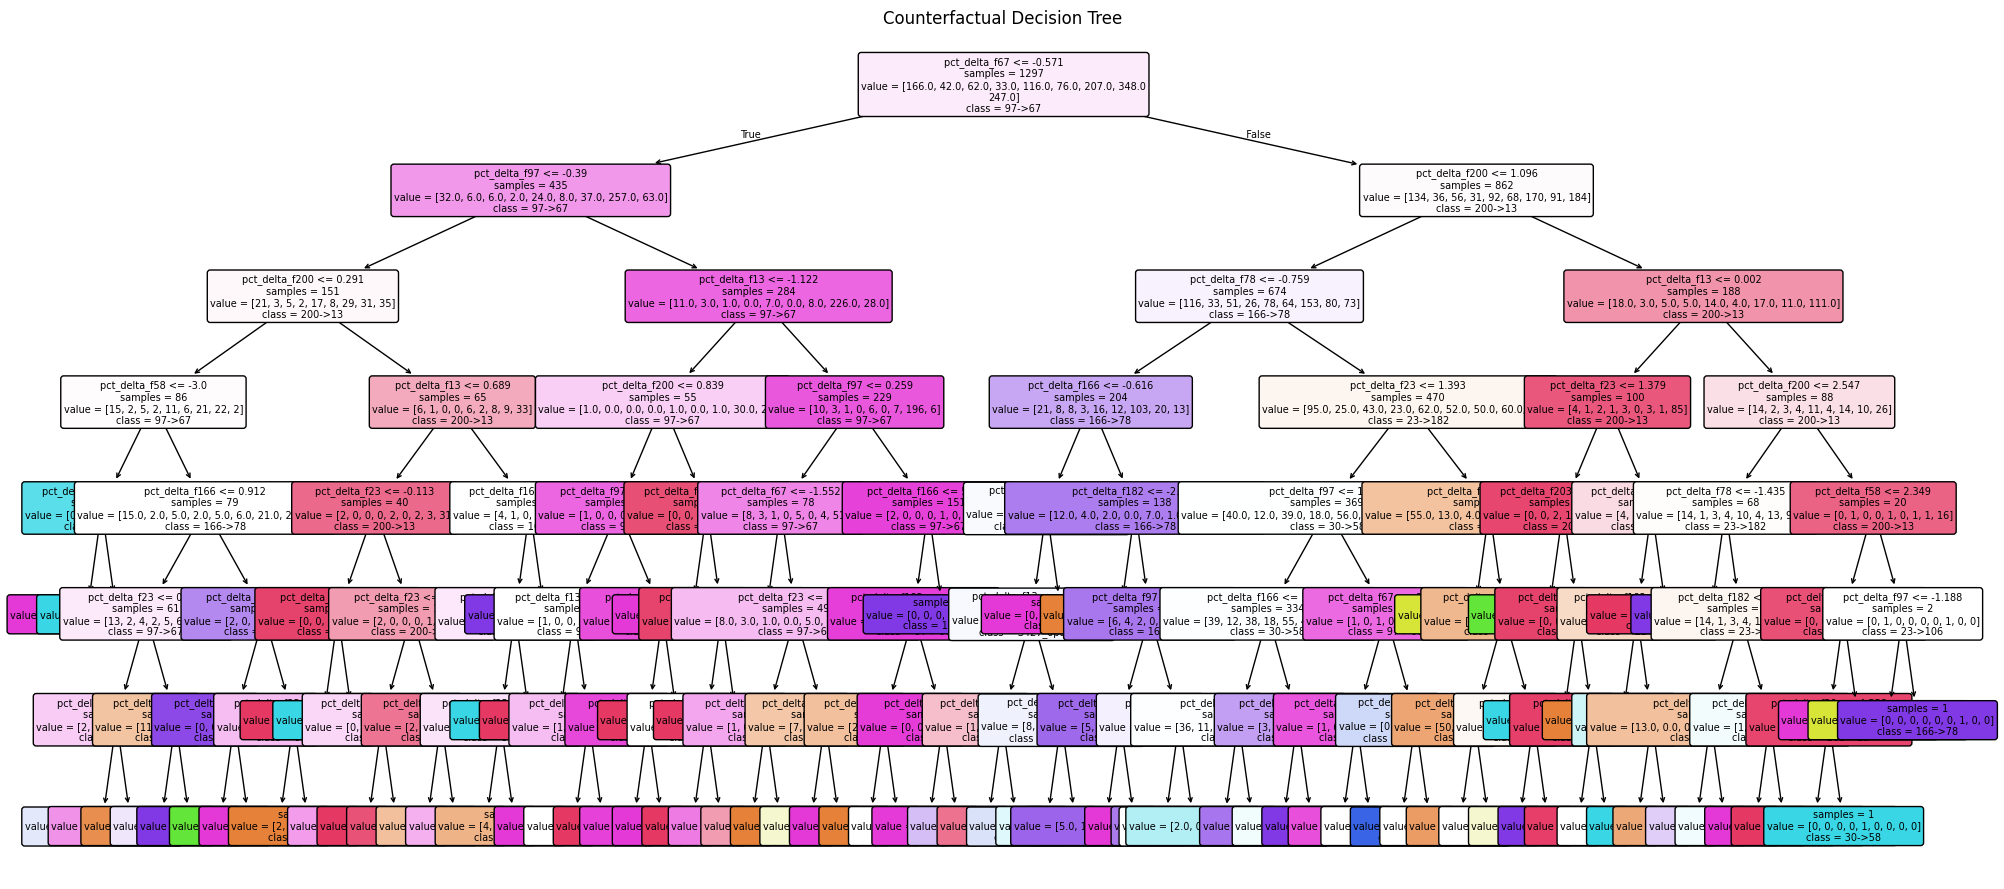

In [33]:
plt.figure(figsize=(24, 11))

plot_tree(
    tree_clf,
    filled  =True ,
    rounded =True ,
    impurity=False,
    fontsize=7    ,
    feature_names=feature_names,
    class_names  =[
        solution_label[int(v)] for v in tree_clf.classes_
    ],
)

plt.title("Counterfactual Decision Tree")

plt.show()

### EXTRACTING RULES

Display each path (separately) leading to leaves that predict the optimal solution:

In [34]:
def show_optimal_leaf_paths(
    leaf_paths
):
    for k, (leaf_id, conds) in enumerate(leaf_paths, start=1):
        print("=" * 40)
        print(f"Path {k}  →  Leaf {leaf_id}")
        print("=" * 40)

        for i, cond in enumerate(conds, start=1):
            print(f"  {i:02d}. {cond}")

        print()


show_optimal_leaf_paths(optimal_leaf_paths)

Path 1  →  Leaf 10
  01. pct_delta_f67 <= -0.5713
  02. pct_delta_f97 <= -0.3896
  03. pct_delta_f200 <= 0.2912
  04. pct_delta_f58 >  -3.0001
  05. pct_delta_f166 <= 0.9120
  06. pct_delta_f23 <= 0.7528
  07. pct_delta_f97 <= -1.2893

Path 2  →  Leaf 89
  01. pct_delta_f67 >  -0.5713
  02. pct_delta_f200 <= 1.0959
  03. pct_delta_f78 <= -0.7592
  04. pct_delta_f166 <= -0.6160
  05. pct_delta_f97 <= 1.6725
  06. pct_delta_f13 >  -1.0141
  07. pct_delta_f30 <= 0.0396

Path 3  →  Leaf 105
  01. pct_delta_f67 >  -0.5713
  02. pct_delta_f200 <= 1.0959
  03. pct_delta_f78 >  -0.7592
  04. pct_delta_f23 <= 1.3929
  05. pct_delta_f97 <= 1.7806
  06. pct_delta_f166 <= 1.2371
  07. pct_delta_f30 <= 2.0205

Path 4  →  Leaf 116
  01. pct_delta_f67 >  -0.5713
  02. pct_delta_f200 <= 1.0959
  03. pct_delta_f78 >  -0.7592
  04. pct_delta_f23 <= 1.3929
  05. pct_delta_f97 >  1.7806
  06. pct_delta_f67 >  2.1424
  07. pct_delta_f23 >  0.0473



Plot only the nodes that belong to the optimal paths:

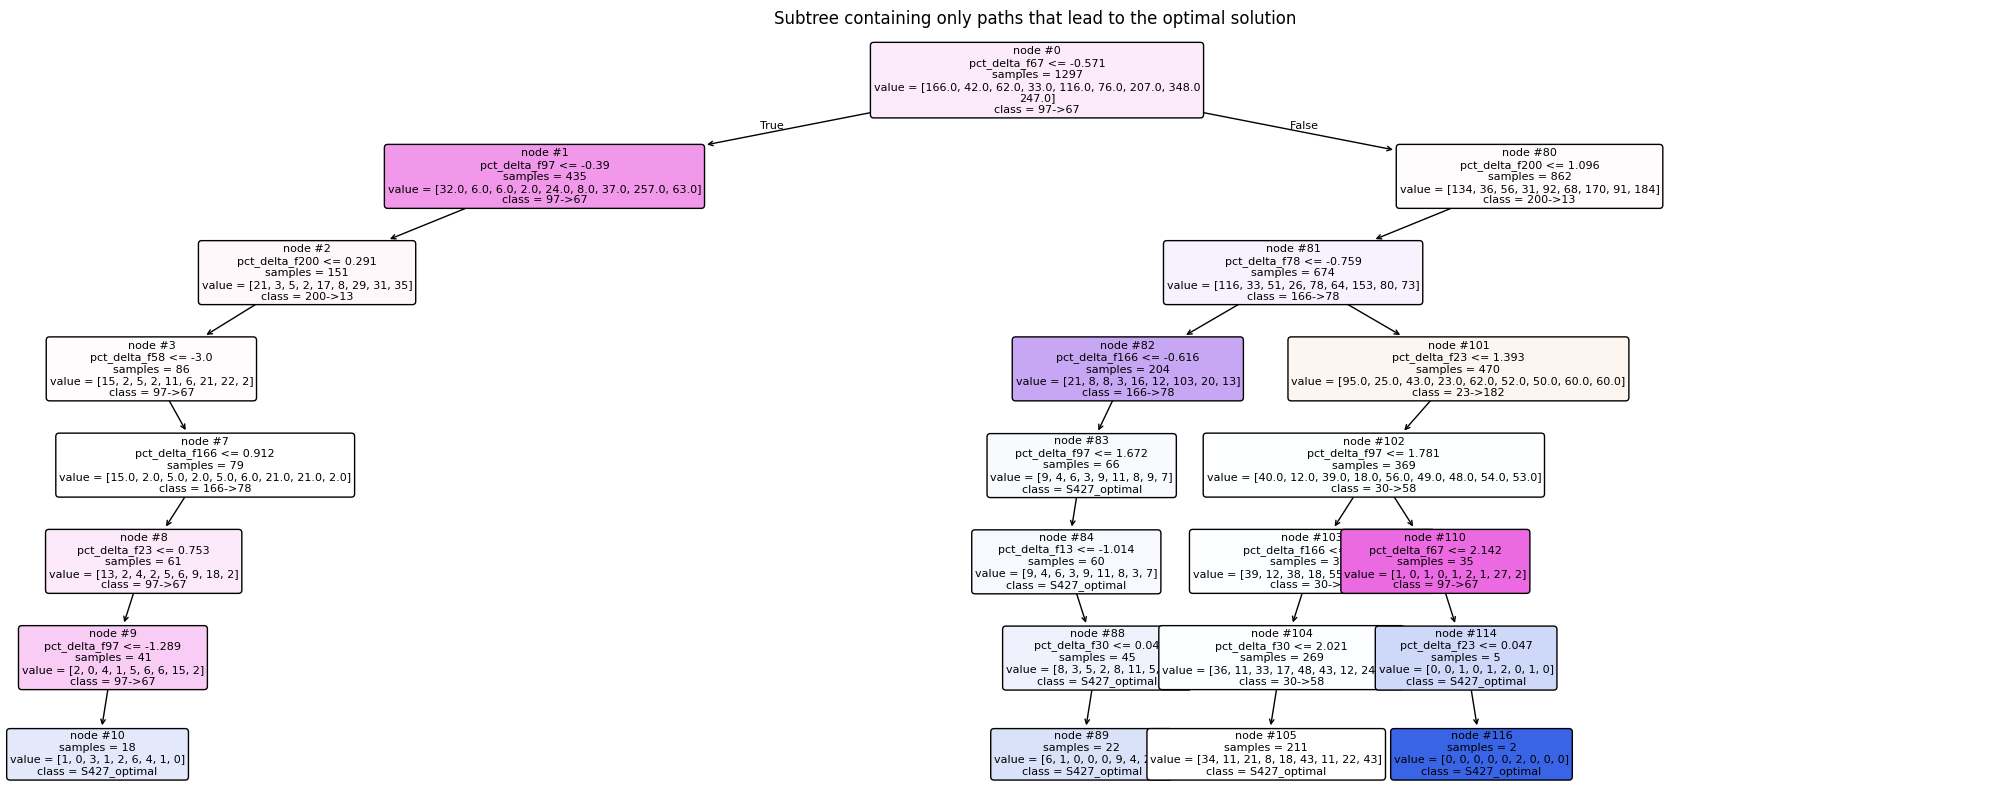

In [35]:
tree_ = tree_clf.tree_

parent = {0: -1}
stack  = [0]

while stack:
    node  = stack.pop()
    left  = tree_.children_left [node]
    right = tree_.children_right[node]

    if left != right:
        parent[left ] = node
        parent[right] = node

        stack.extend([left, right])


keep_nodes = set()

for leaf_id, _ in optimal_leaf_paths:
    n = leaf_id

    while n != -1:
        keep_nodes.add(n)

        n = parent[n]


plt.figure(figsize=(25, 10))

artists = plot_tree(
    tree_clf,
    filled  =True ,
    rounded =True ,
    node_ids=True ,
    impurity=False,
    fontsize=8    ,
    feature_names=feature_names,
    class_names  =[
        solution_label[int(v)] for v in tree_clf.classes_
    ],
)

for artist in artists:
    txt = artist.get_text()

    match = re.search(r"node #(\d+)", txt)
    if match:
        node_id = int(match.group(1))

        if node_id not in keep_nodes:
            artist.set_visible(False)

plt.title("Subtree containing only paths that lead to the optimal solution")

plt.show()